# Quan sát dữ liệu training (sales.csv) — 6 biểu đồ

Chạy từng cell bằng **Shift+Enter**, chart hiện ngay dưới cell.
Nhớ chọn kernel `.venv` (góc phải trên) trước khi chạy.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lunardate import LunarDate
from pathlib import Path

C_REV, C_COGS, C_GRAY, C_ACCENT = "#A32D2D", "#185FA5", "#888780", "#534AB7"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

DATA = Path("../../data")
sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])
sales["margin_pct"] = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"] * 100
print(f"{len(sales)} ngày | {sales['Date'].min().date()} -> {sales['Date'].max().date()}")
sales.head()

3833 ngày | 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,margin_pct
0,2012-07-04,5123547.94,3982991.19,22.261073
1,2012-07-05,2751773.45,2150580.23,21.847482
2,2012-07-06,3054029.42,2517632.84,17.563570
3,2012-07-07,2667930.94,2108246.62,20.978216
4,2012-07-08,2360851.90,1808622.79,23.391095


## 1. Toàn chuỗi: sóng mùa vụ + break 2019

Hình dạng sóng giữ nguyên qua break, chỉ biên độ bị nén ~45%.

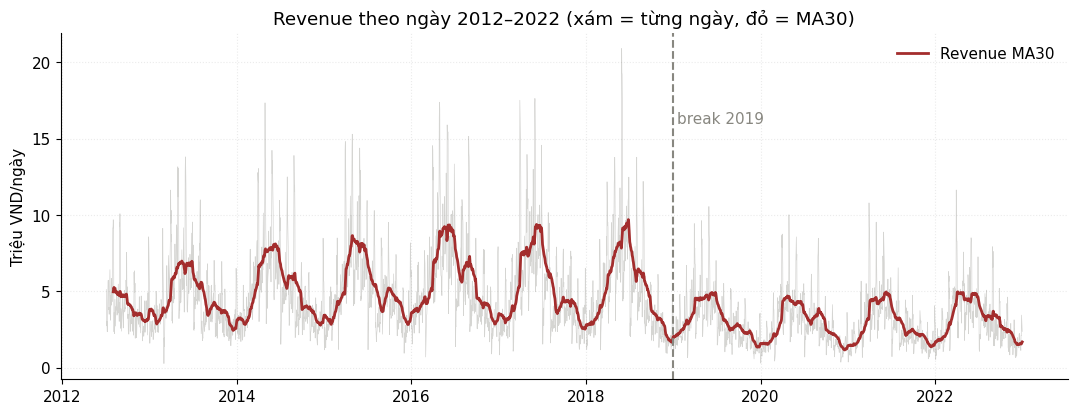

In [3]:
sales["MA30"] = sales["Revenue"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(sales["Date"], sales["Revenue"] / 1e6, color=C_GRAY, alpha=0.35, lw=0.5)
ax.plot(sales["Date"], sales["MA30"] / 1e6, color=C_REV, lw=2, label="Revenue MA30")
ax.axvline(pd.Timestamp("2019-01-01"), color=C_GRAY, ls="--", lw=1.5)
ax.annotate("break 2019", xy=(pd.Timestamp("2019-01-15"), 16), color=C_GRAY)
ax.set_ylabel("Triệu VND/ngày")
ax.set_title("Revenue theo ngày 2012–2022 (xám = từng ngày, đỏ = MA30)")
ax.legend(frameon=False)
plt.show()

## 2. Doanh thu tháng + margin %

Gai margin âm −30..−40% xuất hiện ~2 năm/lần (năm lẻ), trùng mùa sale phá giá.

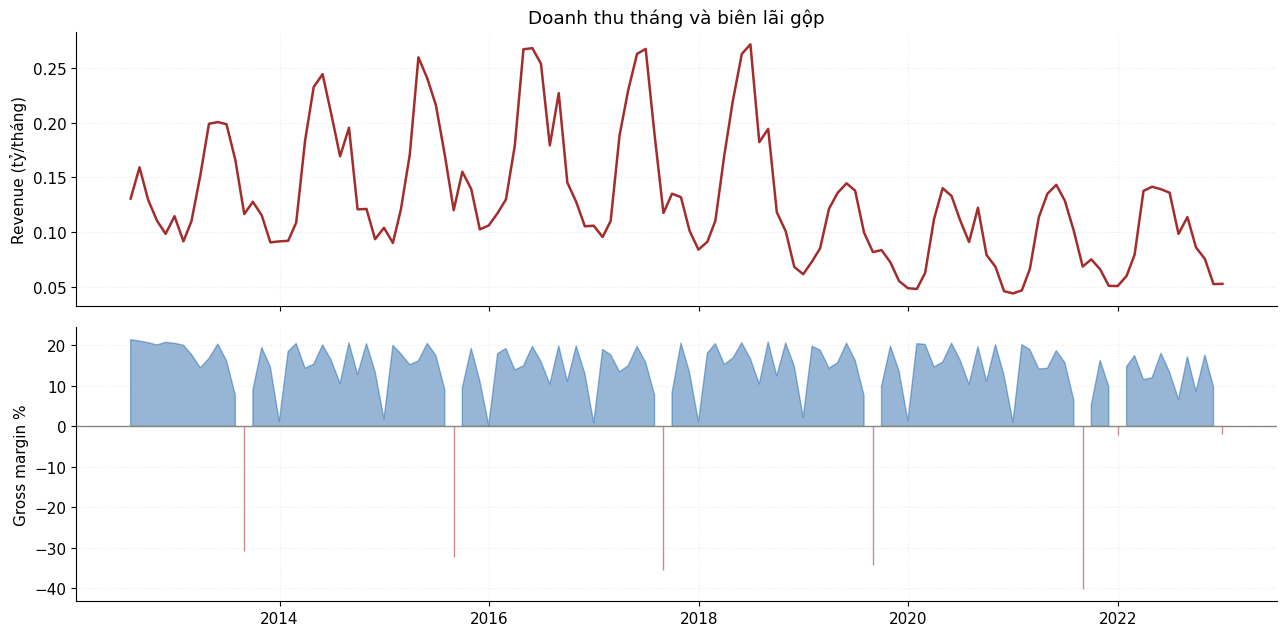

Corr(Revenue, COGS): 0.9760
COGS/Revenue: TB 0.875 ± 0.127


In [4]:
monthly = sales.set_index("Date").resample("ME")[["Revenue", "COGS"]].sum()
monthly["margin_pct"] = (monthly["Revenue"] - monthly["COGS"]) / monthly["Revenue"] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax1.plot(monthly.index, monthly["Revenue"] / 1e9, color=C_REV, lw=1.8)
ax1.set_ylabel("Revenue (tỷ/tháng)")
ax1.set_title("Doanh thu tháng và biên lãi gộp")
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] >= 0, color=C_COGS, alpha=0.45)
ax2.fill_between(monthly.index, monthly["margin_pct"], 0,
                 where=monthly["margin_pct"] < 0, color=C_REV, alpha=0.55)
ax2.axhline(0, color=C_GRAY, lw=1)
ax2.set_ylabel("Gross margin %")
plt.tight_layout()
plt.show()

print(f"Corr(Revenue, COGS): {sales['Revenue'].corr(sales['COGS']):.4f}")
print(f"COGS/Revenue: TB {(sales['COGS']/sales['Revenue']).mean():.3f} ± {(sales['COGS']/sales['Revenue']).std():.3f}")

## 3. Heatmap năm × tháng

Đỉnh T4–T6, đáy T11–T12, đậm nhất 2016–2018, sáng dần từ 2019.

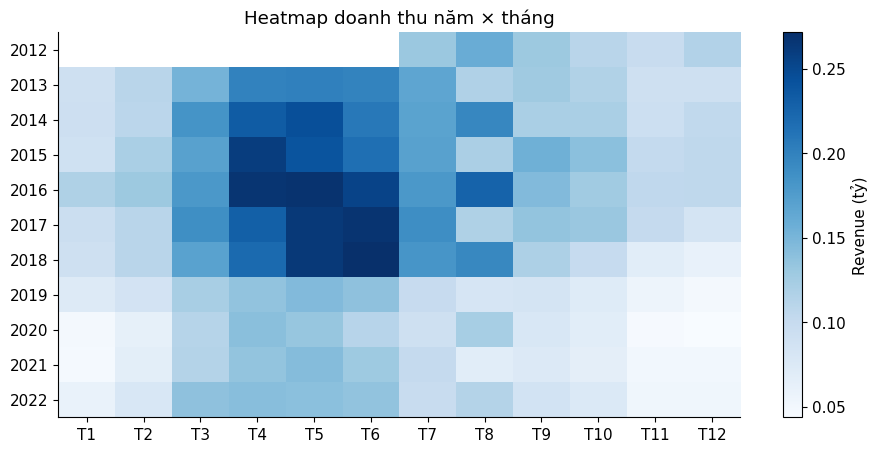

In [5]:
hm = sales.pivot_table(index=sales["Date"].dt.year, columns=sales["Date"].dt.month,
                       values="Revenue", aggfunc="sum") / 1e9

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(hm.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(12), [f"T{m}" for m in range(1, 13)])
ax.set_yticks(range(len(hm.index)), hm.index)
ax.grid(False)
fig.colorbar(im, label="Revenue (tỷ)")
ax.set_title("Heatmap doanh thu năm × tháng")
plt.show()

## 4. Mùa vụ có bền vững không? (chart quan trọng nhất)

10 đường xám gần đè lên nhau → mùa vụ lặp ổn định, TRỪ tháng 8 (±2,15 điểm %, do Mid-Year Sale năm có năm không).

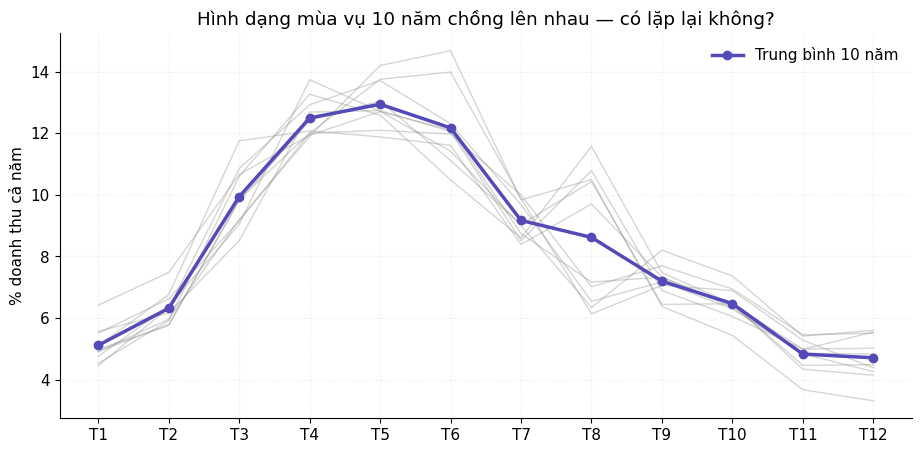

Tỷ trọng tháng TB ± std (T8 bất ổn nhất):
month
1      5.11% ± 0.58
2      6.32% ± 0.53
3      9.95% ± 1.01
4      12.5% ± 0.64
5     12.95% ± 0.74
6     12.18% ± 1.27
7      9.17% ± 0.62
8      8.62% ± 2.15
9       7.2% ± 0.55
10     6.47% ± 0.53
11     4.83% ± 0.55
12     4.71% ± 0.74


In [6]:
yr = sales[sales["Date"].dt.year.between(2013, 2022)].copy()
yr["year"], yr["month"] = yr["Date"].dt.year, yr["Date"].dt.month
share = (yr.groupby(["year", "month"])["Revenue"].sum()
         / yr.groupby("year")["Revenue"].sum()).unstack() * 100

fig, ax = plt.subplots(figsize=(11, 5))
for y in share.index:
    ax.plot(share.columns, share.loc[y], color=C_GRAY, alpha=0.35, lw=1)
ax.plot(share.columns, share.mean(), color=C_ACCENT, lw=2.5, marker="o",
        label="Trung bình 10 năm")
ax.set_xticks(range(1, 13), [f"T{m}" for m in range(1, 13)])
ax.set_ylabel("% doanh thu cả năm")
ax.set_title("Hình dạng mùa vụ 10 năm chồng lên nhau — có lặp lại không?")
ax.legend(frameon=False)
plt.show()

print("Tỷ trọng tháng TB ± std (T8 bất ổn nhất):")
print((share.mean().round(2).astype(str) + "% ± " + share.std().round(2).astype(str)).to_string())

## 5. Thứ trong tuần

Đỉnh thứ Tư, đáy thứ Bảy, chênh ~20% — khách đặt hàng trong tuần, không phải cuối tuần.

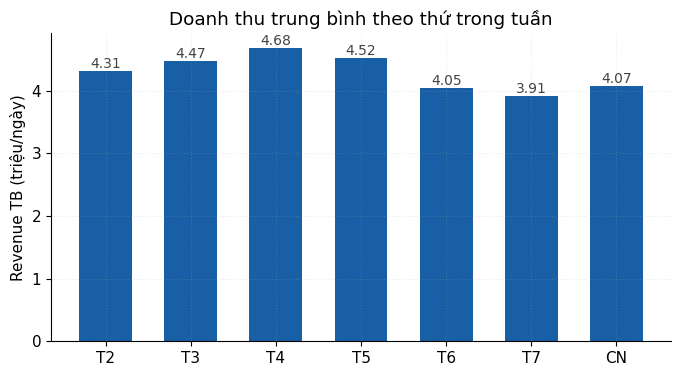

Chênh đỉnh (T4) vs đáy (T7): 19.8%


In [7]:
dow = sales.groupby(sales["Date"].dt.dayofweek)["Revenue"].mean() / 1e6
labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, dow.values, color=C_COGS, width=0.62)
for i, v in enumerate(dow.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10, color="#444441")
ax.set_ylabel("Revenue TB (triệu/ngày)")
ax.set_title("Doanh thu trung bình theo thứ trong tuần")
plt.show()

print(f"Chênh đỉnh (T4) vs đáy (T7): {(dow.max()/dow.min()-1)*100:.1f}%")

## 6. Hiệu ứng Tết ±30 ngày

Đáy −25 ngày, sụt quanh mồng 1, bùng nổ +25..+30 ngày (gấp đôi đáy). Bắt buộc có feature lịch âm.

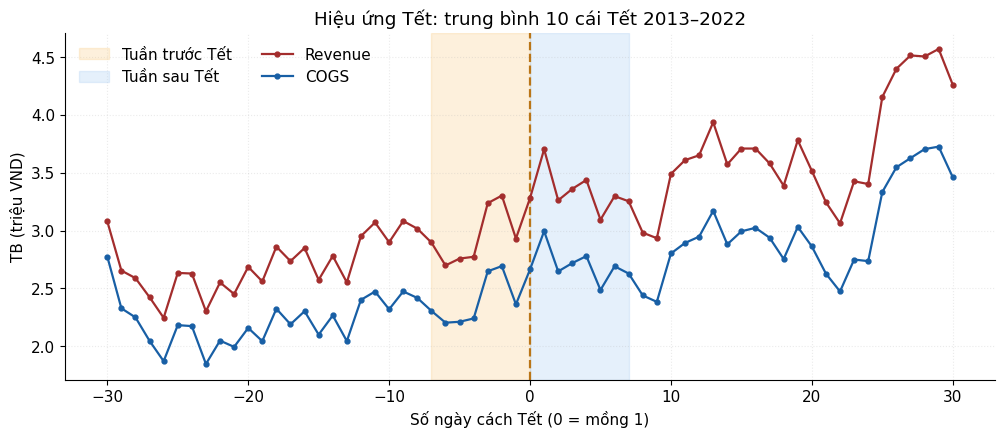

In [8]:
tet_dates = [pd.Timestamp(LunarDate(y, 1, 1).to_solar_date()) for y in range(2013, 2023)]
frames = []
for t in tet_dates:
    w = sales[(sales["Date"] >= t - pd.Timedelta(days=30)) &
              (sales["Date"] <= t + pd.Timedelta(days=30))].copy()
    w["offset"] = (w["Date"] - t).dt.days
    frames.append(w)
avg = pd.concat(frames).groupby("offset")[["Revenue", "COGS"]].mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axvspan(-7, 0, color="#FAC775", alpha=0.25, label="Tuần trước Tết")
ax.axvspan(0, 7, color="#B5D4F4", alpha=0.35, label="Tuần sau Tết")
ax.axvline(0, color="#BA7517", ls="--", lw=1.6)
ax.plot(avg.index, avg["Revenue"], "o-", color=C_REV, ms=3.5, lw=1.6, label="Revenue")
ax.plot(avg.index, avg["COGS"], "o-", color=C_COGS, ms=3.5, lw=1.6, label="COGS")
ax.set_xlabel("Số ngày cách Tết (0 = mồng 1)")
ax.set_ylabel("TB (triệu VND)")
ax.set_title("Hiệu ứng Tết: trung bình 10 cái Tết 2013–2022")
ax.legend(frameon=False, ncol=2)
plt.show()

## 7. Decompose theo category (join order_items + products)

Dùng `order_items` join `products` (lấy `category`, `cogs` catalog) — join này khớp tuyệt đối
`sales.csv` (Phase 0 QC: sai lệch ~1e-9, coi như 0), nên **an toàn để phân rã gross_revenue theo category**.
`gross_revenue = quantity * unit_price`, `gross_cogs = quantity * cogs` — cùng công thức gross như sales.csv,
tính trên TẤT CẢ đơn kể cả cancelled (không phải net_revenue kinh doanh).


In [ ]:
OUT = Path("../output/phase1")   # chart Phase 1 -> EDA_Insight/output/phase1/
OUT.mkdir(parents=True, exist_ok=True)
EXPORT = Path("data")            # data trung gian Phase 1 -> EDA_Insight/phase1_descriptive/data/
EXPORT.mkdir(exist_ok=True)

order_items = pd.read_csv(DATA / "order_items.csv",
                          usecols=["order_id", "product_id", "quantity", "unit_price", "discount_amount"])
products = pd.read_csv(DATA / "products.csv", usecols=["product_id", "category", "cogs"])
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"],
                      usecols=["order_id", "order_date", "zip", "order_status"])
geography = pd.read_csv(DATA / "geography.csv", usecols=["zip", "region"])

li = (order_items
      .merge(orders, on="order_id", how="left")
      .merge(products, on="product_id", how="left")
      .merge(geography, on="zip", how="left"))
li["gross_revenue"] = li["quantity"] * li["unit_price"]
li["gross_cogs"] = li["quantity"] * li["cogs"]

# sanity check với sales.csv — phải xấp xỉ 0
daily_gross = li.groupby("order_date")["gross_revenue"].sum()
target = sales.set_index("Date")["Revenue"]
diff_pct = ((daily_gross.reindex(target.index) - target).abs() / target).mean() * 100
print(f"Sanity check gross rebuilt vs sales.csv: sai lệch TB {diff_pct:.4f}% (kỳ vọng ~0%)\n")

cat = li.groupby("category").agg(gross_revenue=("gross_revenue", "sum"),
                                  gross_cogs=("gross_cogs", "sum"))
cat["gross_profit"] = cat["gross_revenue"] - cat["gross_cogs"]
cat["margin_pct"] = cat["gross_profit"] / cat["gross_revenue"] * 100
cat["share_pct"] = cat["gross_revenue"] / cat["gross_revenue"].sum() * 100
cat = cat.sort_values("gross_revenue", ascending=False)
print("Bảng category (gross, toàn kỳ 2012-2022):")
print(cat.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(cat.index[::-1], cat["share_pct"][::-1], color=C_ACCENT)
for b, (share, margin) in zip(bars, zip(cat["share_pct"][::-1], cat["margin_pct"][::-1])):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2,
            f"{share:.1f}% doanh thu | margin {margin:.1f}%", va="center", fontsize=9, color="#444441")
ax.set_xlabel("% tổng gross_revenue")
ax.set_title("Doanh thu & margin theo category (gross, toàn kỳ)")
ax.set_xlim(0, max(cat["share_pct"]) * 1.5)
plt.tight_layout()
plt.savefig(OUT / "22_category_decompose.png", dpi=130)
plt.show()

**Đọc số:** category chiếm tỷ trọng doanh thu lớn nhất chưa chắc margin cao nhất — category
tỷ trọng nhỏ nhưng margin cao hơn có thể là cơ hội tăng lãi mà không cần tăng nhiều doanh thu.
Category có margin thấp nhất là ứng viên đầu tiên cần điều tra ở Phase 2 (liên hệ W2: 18.6% dòng
bán dưới giá vốn — có tập trung ở category nào không?).


## 8. Decompose theo region (join order_items + orders + geography)

`orders.zip` → `geography.region` (join sạch 100%, đã xác nhận ở Phase 0). Cùng công thức gross như
mục 7, gộp theo `region` thay vì `category`.


In [ ]:
reg = li.groupby("region").agg(gross_revenue=("gross_revenue", "sum"),
                                gross_cogs=("gross_cogs", "sum"))
reg["gross_profit"] = reg["gross_revenue"] - reg["gross_cogs"]
reg["margin_pct"] = reg["gross_profit"] / reg["gross_revenue"] * 100
reg["share_pct"] = reg["gross_revenue"] / reg["gross_revenue"].sum() * 100
reg = reg.sort_values("gross_revenue", ascending=False)
print("Bảng region (gross, toàn kỳ 2012-2022):")
print(reg.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(reg.index, reg["share_pct"], color=C_COGS, width=0.55)
for b, margin in zip(bars, reg["margin_pct"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
            f"{b.get_height():.1f}%\nmargin {margin:.1f}%", ha="center", fontsize=9, color="#444441")
ax.set_ylabel("% tổng gross_revenue")
ax.set_title("Doanh thu & margin theo region (gross, toàn kỳ)")
ax.set_ylim(0, max(reg["share_pct"]) * 1.35)
plt.tight_layout()
plt.savefig(OUT / "23_region_decompose.png", dpi=130)
plt.show()

## 7b. Export bảng category/region decompose (cho `DATA_LINEAGE.md`)

Gộp lại 2 bảng `cat` (mục 7) và `reg` (mục 8) đã tính ở trên thành 1 file, KHÔNG tính lại số mới —
chỉ export đúng số đã in ra ở 2 cell phía trên (khớp mục 2.4-2.5 `descriptive_summary.md`).

In [ ]:
cat_export = cat.reset_index().rename(columns={"category": "dim_value"})
cat_export.insert(0, "dimension", "category")
reg_export = reg.reset_index().rename(columns={"region": "dim_value"})
reg_export.insert(0, "dimension", "region")
category_region_decompose = pd.concat([cat_export, reg_export], ignore_index=True)
category_region_decompose.to_csv(EXPORT / "category_region_decompose.csv", index=False)
print(f"Da luu {EXPORT / 'category_region_decompose.csv'} ({len(category_region_decompose)} dong)")
category_region_decompose

**Đọc số:** region đóng góp doanh thu nhiều nhất không nhất thiết margin cao nhất — nếu region
nhỏ hơn nhưng margin nhỉnh hơn, đó là tín hiệu tốt cho việc phân bổ ngân sách marketing/khuyến mãi
ở Phase 2/3, KHÔNG phải kết luận nhân quả (region margin cao có thể do cơ cấu category khác, chưa
kiểm soát biến nhiễu).


## 9. Gross vs Net revenue — đối chiếu độ lệch

Theo Phase 0 QC (W1): `sales.Revenue` là **gross** — tính TẤT CẢ đơn kể cả `cancelled`, KHÔNG trừ
`discount_amount`. Ở đây tính thêm **net_revenue** (view kinh doanh thực tế): loại đơn `cancelled`,
trừ `discount_amount` từng dòng. Hai khái niệm phục vụ 2 mục đích khác nhau — **gross_revenue dùng
cho forecast Phần B (khớp target), net_revenue dùng cho phân tích kinh doanh (doanh thu "thật" công
ty ghi nhận)**. Không dùng lẫn hai con số này khi so sánh.


In [ ]:
li_net = li[li["order_status"] != "cancelled"].copy()
li_net["net_revenue"] = li_net["quantity"] * li_net["unit_price"] - li_net["discount_amount"]

gross_monthly = li.set_index("order_date")["gross_revenue"].resample("ME").sum() / 1e9
net_monthly = li_net.set_index("order_date")["net_revenue"].resample("ME").sum() / 1e9

gross_total = li["gross_revenue"].sum()
net_total = li_net["net_revenue"].sum()
gap_pct = (1 - net_total / gross_total) * 100

print(f"Tổng gross_revenue (2012-2022): {gross_total/1e9:,.2f} tỷ VND")
print(f"Tổng net_revenue   (2012-2022): {net_total/1e9:,.2f} tỷ VND")
print(f"Chênh lệch (gap)               : {gap_pct:.2f}% — do loại đơn cancelled + trừ discount")

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(gross_monthly.index, gross_monthly, color=C_REV, lw=1.8, label="Gross revenue (khớp sales.csv)")
ax.plot(net_monthly.index, net_monthly, color=C_ACCENT, lw=1.8, label="Net revenue (loại cancelled, trừ discount)")
ax.fill_between(gross_monthly.index, gross_monthly, net_monthly, color=C_GRAY, alpha=0.25,
                label="Gap = hủy đơn + chiết khấu")
ax.set_ylabel("Tỷ VND / tháng")
ax.set_title(f"Gross vs Net revenue theo tháng — gap toàn kỳ {gap_pct:.1f}%")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(OUT / "24_gross_vs_net_reconcile.png", dpi=130)
plt.show()

## 9b. Export bảng gross/net revenue THEO NGÀY (cho `DATA_LINEAGE.md`)

`gross_revenue`/`COGS` lấy trực tiếp từ `sales.csv` (đã xác nhận = gross theo Phase 0, khớp 100%).
`net_revenue` = tổng theo ngày của `li_net["net_revenue"]` đã tính ở cell trên (loại `cancelled`,
trừ `discount_amount`). Khớp mục 2.6 `descriptive_summary.md`.

In [ ]:
daily_net = li_net.groupby("order_date")["net_revenue"].sum().rename("net_revenue")
daily_revenue_gross_net = (
    sales.set_index("Date")[["Revenue", "COGS"]]
    .rename(columns={"Revenue": "gross_revenue"})
    .join(daily_net)
    .fillna({"net_revenue": 0})
    .reset_index()
    .rename(columns={"index": "Date"})
)
daily_revenue_gross_net = daily_revenue_gross_net[["Date", "gross_revenue", "net_revenue", "COGS"]]
daily_revenue_gross_net.to_csv(EXPORT / "daily_revenue_gross_net.csv", index=False)

print(f"Da luu {EXPORT / 'daily_revenue_gross_net.csv'} ({len(daily_revenue_gross_net):,} ngay)")
print(f"Tong gross_revenue: {daily_revenue_gross_net['gross_revenue'].sum()/1e9:.2f} ty VND")
print(f"Tong net_revenue  : {daily_revenue_gross_net['net_revenue'].sum()/1e9:.2f} ty VND")
daily_revenue_gross_net.head()

**Đọc số:** gap ~13% giữa gross và net đến từ 2 nguồn: (1) đơn `cancelled` (~9.2% tổng đơn) vẫn được
tính vào gross_revenue theo định nghĩa `sales.csv`, dù công ty không thu được tiền; (2) `discount_amount`
bị trừ khi tính net. Đây KHÔNG phải sai số dữ liệu — là 2 định nghĩa metric khác nhau, phải chọn đúng
cái cần dùng theo mục đích (forecast Phần B → gross; báo cáo kinh doanh → net).


## Chốt feature cho model Phần B

| Quan sát | Feature | Độ mạnh |
|---|---|---|
| Sóng mùa vụ tháng ổn định | month / Fourier | Mạnh nhất |
| Break 2019 | regime flag hoặc train từ 2019 | Mạnh |
| Hiệu ứng Tết | days_from_tet (lịch âm) | Mạnh |
| DoW chênh 20% | day_of_week | Vừa |
| Sale năm lẻ, T8 bất ổn | flag năm lẻ + mùa sale | Vừa |
| COGS bám Revenue (corr 0,976) | dự báo ratio + flag sale | — |